# Figure 6a: Density-layer volume transport

Plots the density-layer based volume transport (Sv) across 30S using
the layer definitions of Talley (2008). The dark blue bars are the
integrated totals per layer and can be compared with the magenta lines
(observed values); the narrow red bars are equal subdivisions of each
layer.

Russell, J.L., et al. (2018), Metrics for the evaluation of the Southern Ocean in coupled climate models and earth system models, *J. Geophysical Research - Oceans*, 123, 3120-3143, [doi:10.1002/2017JC013461](https://doi.org/10.1002/2017JC013461).

---

### About these notebooks

This notebook is one of a set reproducing the figures of Russell et al.
(2018), a suite of metrics for evaluating the Southern Ocean in coupled
climate and earth system models.

They are a Python translation of the NCL diagnostics distributed with
[ESMValTool](https://github.com/ESMValGroup/ESMValTool)
(`esmvaltool/diag_scripts/russell18jgr/`, driven by
`recipe_russell18jgr.yml`), rewritten so that each figure stands alone
and can be run interactively without going through a recipe.

Translated and maintained by **Romain Beucher**,
[ACCESS-NRI](https://www.access-nri.org.au).
Please contact <romain.beucher@anu.edu.au> with any questions.

## Scientific background

Water crossing 30S does so in layers of differing density, and the net
effect of those layers is the Southern Ocean's contribution to the
global overturning circulation: light water moving one way near the
surface is compensated by denser water moving the other way at depth.

The layers follow the definitions of Talley (2008) and the magenta lines
are her observational estimates, so the comparison is direct. In a
steady state the net transport (the top bar) should be close to zero; a
large net value points to a problem with the model's mass budget or with
the grid-cell volumes used here.

## Setup

This notebook is standalone: everything it needs is defined below.  It
requires `esmvalcore`, `iris`, `numpy`, `matplotlib` and `cartopy` -
the full ESMValTool is *not* needed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## Helper functions

The helpers below are the parts of the original NCL diagnostic that are
worth keeping out of the way of the plotting code.  They are defined
here rather than imported so the notebook stands on its own.

In [9]:
import iris


# Constants used by the original NCL scripts
EARTH_RADIUS = 6.37e06   # m
DEG2RAD = 0.0174533


def coord_1d_or_2d(cube, axis):
    """Latitude/longitude points, which may be 1D or 2D.

    ESMValTool preprocessed ocean files carry either 1D dimension
    coordinates (regular grids) or 2D auxiliary coordinates
    (curvilinear grids); this hides the difference.
    """
    return np.asarray(cube.coord(axis).points)


def lat_1d(cube):
    """A representative 1D latitude array (column 0 for 2D grids)."""
    lat = coord_1d_or_2d(cube, "latitude")
    return lat[:, 0] if lat.ndim == 2 else lat


def lon_1d(cube):
    """A representative 1D longitude array (row 0 for 2D grids)."""
    lon = coord_1d_or_2d(cube, "longitude")
    return lon[0, :] if lon.ndim == 2 else lon


def closest_index(value, array):
    """Index of the array element closest to value (NCL closest_val)."""
    array = np.asarray(array, dtype=float)
    return int(np.nanargmin(np.abs(array - value)))


def time_mean(cube):
    """Average over the time dimension, if there is one."""
    if any(c.name() == "time" for c in cube.coords()):
        if cube.coord("time").shape[0] > 1:
            return cube.collapsed("time", iris.analysis.MEAN)
    return cube


def depth_to_dbar(depth):
    """Approximate pressure (decibars) from depth (m), as in NCL/POP."""
    depth = np.asarray(depth, dtype=float)
    bars = (0.059808 * (np.exp(-0.025 * depth) - 1.0)
            + 0.100766 * depth + 2.28405e-7 * depth ** 2)
    return 10.0 * bars


def rho_mwjf(theta, salt, depth):
    """Potential density (McDougall, Wright, Jackett & Feistel 2003).

    Port of NCL's ``rho_mwjf``, the equation of state used by the POP
    ocean model.  ``theta`` is potential temperature in degrees
    Celsius, ``salt`` is salinity in psu and ``depth`` is the reference
    depth in metres (0, 1977 and 3948 m give reference pressures of
    about 0, 2000 and 4000 dbar).  Returns density in g/cm^3, which the
    caller converts to a sigma value with ``1000 * (rho - 1)``.

    Check value: rho(35 psu, 25 C, 2000 dbar) = 1031.654229 kg/m^3.
    """
    t = np.ma.masked_invalid(np.ma.asarray(theta, dtype=float))
    s = np.ma.masked_invalid(np.ma.asarray(salt, dtype=float))
    s = np.ma.where(s < 0.0, 0.0, s)
    p = float(depth_to_dbar(depth))
    p001 = 0.001   # scales the numerator so that rho is in g/cm^3

    # numerator coefficients
    nums0t0 = (9.99843699e+2 * p001 + p * (1.04004591e-2 * p001
                                           + p * -3.24041825e-8 * p001))
    nums0t1 = 7.35212840e+0 * p001
    nums0t2 = (-5.45928211e-2 * p001 + p * (1.03970529e-7 * p001
                                            + p * -1.23869360e-11 * p001))
    nums0t3 = 3.98476704e-4 * p001
    nums1t0 = 2.96938239e+0 * p001 + p * 5.18761880e-6 * p001
    nums1t1 = -7.23268813e-3 * p001
    nums2t0 = 2.12382341e-3 * p001

    # denominator coefficients
    dens0t0 = 1.0e+0 + p * 5.30848875e-6
    dens0t1 = 7.28606739e-3 + (p ** 3) * -1.27934137e-17
    dens0t2 = -4.60835542e-5
    dens0t3 = 3.68390573e-7 + (p ** 2) * -3.03175128e-16
    dens0t4 = 1.80809186e-10
    dens1t0 = 2.14691708e-3
    dens1t1 = -9.27062484e-6
    dens1t3 = -1.78343643e-10
    densqt0 = 4.76534122e-6
    densqt1 = 1.63410736e-9

    numerator = (nums0t0 + t * (nums0t1 + t * (nums0t2 + nums0t3 * t))
                 + s * (nums1t0 + nums1t1 * t + nums2t0 * s))
    denominator = (dens0t0
                   + t * (dens0t1
                          + t * (dens0t2 + t * (dens0t3 + dens0t4 * t)))
                   + s * (dens1t0 + dens1t1 * t + dens1t3 * t ** 3)
                   + s * np.ma.sqrt(s) * (densqt0 + densqt1 * t ** 2))
    return numerator / denominator


# Density layers of Talley (2003, J. Phys. Oceanogr. 33, 530-560).
# Each condition is (sigma variable, lower bound, upper bound); all
# conditions of a layer are combined with AND, and None is unbounded.
# 's0', 's2' and 's4' are the potential density anomalies referenced to
# 0, 2000 and 4000 dbar.
MAIN_LAYERS = [
    [("s0", None, 26.10)],
    [("s0", 26.10, 26.40)],
    [("s0", 26.40, 26.90)],
    [("s0", 26.90, 27.10)],
    [("s0", 27.10, 27.40)],
    [("s0", 27.40, None), ("s2", None, 36.80)],
    [("s2", 36.80, None), ("s4", None, 45.80)],
    [("s4", 45.80, 45.86)],
    [("s4", 45.86, 45.92)],
    [("s4", 45.92, 46.00)],
    [("s4", 46.00, None)],
]

# Four equal subdivisions of each main layer (the narrow red bars)
SUB_LAYERS = [
    [("s0", None, 24.900)], [("s0", 24.900, 25.300)],
    [("s0", 25.300, 25.700)], [("s0", 25.700, 26.100)],
    [("s0", 26.100, 26.175)], [("s0", 26.175, 26.250)],
    [("s0", 26.250, 26.325)], [("s0", 26.325, 26.400)],
    [("s0", 26.400, 26.525)], [("s0", 26.525, 26.650)],
    [("s0", 26.650, 26.775)], [("s0", 26.775, 26.900)],
    [("s0", 26.900, 26.950)], [("s0", 26.950, 27.000)],
    [("s0", 27.000, 27.050)], [("s0", 27.050, 27.100)],
    [("s0", 27.100, 27.175)], [("s0", 27.175, 27.250)],
    [("s0", 27.250, 27.325)], [("s0", 27.325, 27.400)],
    [("s0", 27.400, 27.500)],
    [("s0", 27.500, None), ("s2", None, 36.700)],
    [("s2", 36.700, 36.750)], [("s2", 36.750, 36.800)],
    [("s2", 36.800, 36.850)], [("s2", 36.850, 36.900)],
    [("s2", 36.900, 36.950)],
    [("s2", 36.950, None), ("s4", None, 45.800)],
    [("s4", 45.800, 45.815)], [("s4", 45.815, 45.830)],
    [("s4", 45.830, 45.845)], [("s4", 45.845, 45.860)],
    [("s4", 45.860, 45.875)], [("s4", 45.875, 45.890)],
    [("s4", 45.890, 45.905)], [("s4", 45.905, 45.920)],
    [("s4", 45.920, 45.940)], [("s4", 45.940, 45.960)],
    [("s4", 45.960, 45.980)], [("s4", 45.980, 46.000)],
    [("s4", 46.000, 46.050)], [("s4", 46.050, 46.100)],
    [("s4", 46.100, 46.150)], [("s4", 46.150, None)],
]

LAYER_LABELS = ["Net", "Surface", r"26.10$\sigma_0$", r"26.40$\sigma_0$",
                r"26.90$\sigma_0$", r"27.10$\sigma_0$",
                r"27.40$\sigma_0$", r"36.8$\sigma_2$",
                r"45.8$\sigma_4$", r"45.86$\sigma_4$",
                r"45.92$\sigma_4$", r"46.0$\sigma_4$", "Bottom"]


def layer_mask(sigma, conditions):
    """Boolean mask for one (sub)layer definition."""
    mask = np.ones(sigma["s0"].shape, dtype=bool)
    for var, lower, upper in conditions:
        if lower is not None:
            mask &= np.ma.filled(sigma[var] >= lower, False)
        if upper is not None:
            mask &= np.ma.filled(sigma[var] < upper, False)
    return mask


def layer_sums(sigma, transport):
    """Transport per main layer (12, incl. net) and sublayer (44)."""
    main = np.zeros(12)
    for i, conditions in enumerate(MAIN_LAYERS):
        value = np.ma.masked_where(
            ~layer_mask(sigma, conditions), transport).sum()
        main[i + 1] = 0.0 if np.ma.is_masked(value) else float(value)
    main[0] = main[1:].sum()

    sub = np.zeros(44)
    for i, conditions in enumerate(SUB_LAYERS):
        value = np.ma.masked_where(
            ~layer_mask(sigma, conditions), transport).sum()
        sub[i] = 0.0 if np.ma.is_masked(value) else float(value)
    return main, sub


def interp_to_lat(cube, exact_lat):
    """Linear interpolation of a (lev, lat, lon) field to one latitude."""
    data = np.ma.masked_invalid(cube.data)
    lat = lat_1d(cube)
    if lat[0] > lat[-1]:                 # ensure ascending
        lat, data = lat[::-1], data[:, ::-1, :]
    k = int(np.clip(int(np.searchsorted(lat, exact_lat)) - 1,
                    0, len(lat) - 2))
    weight = float(np.clip((exact_lat - lat[k]) / (lat[k + 1] - lat[k]),
                           0.0, 1.0))
    return (1.0 - weight) * data[:, k, :] + weight * data[:, k + 1, :]


def interp_to_lon(field, src_lon, dst_lon):
    """Cyclic linear interpolation of a (lev, lon) field in longitude."""
    src_lon = np.mod(np.asarray(src_lon, dtype=float), 360.0)
    dst_lon = np.mod(np.asarray(dst_lon, dtype=float), 360.0)
    if len(src_lon) < 2 or not np.all(np.diff(src_lon) > 0):
        return field          # not monotonic: use as-is, as NCL did
    out = np.ma.masked_all((field.shape[0], len(dst_lon)))
    src_ext = np.concatenate(
        [src_lon[-1:] - 360.0, src_lon, src_lon[:1] + 360.0])
    for k in range(field.shape[0]):
        row = np.ma.filled(field[k], np.nan)
        out[k] = np.ma.masked_invalid(np.interp(
            dst_lon, src_ext, np.concatenate([row[-1:], row, row[:1]])))
    return out


def prepare_section(thetao_cube, so_cube, vo_cube, volcello_cube):
    """Everything needed at the 30S section of the vo grid.

    Temperature and salinity are interpolated onto the vo grid, the
    potential densities referenced to 0/2000/4000 dbar are computed,
    and volcello is divided by the north-south grid distance to give
    the cross-section area of each cell.
    """
    theta, salt, vo = (time_mean(thetao_cube), time_mean(so_cube),
                       time_mean(vo_cube))
    vo_lat, vo_lon = lat_1d(vo), lon_1d(vo)
    a = closest_index(-30.0, vo_lat)
    exact_lat = float(vo_lat[a])

    theta_sec = interp_to_lon(interp_to_lat(theta, exact_lat),
                              lon_1d(theta), vo_lon)
    so_sec = interp_to_lon(interp_to_lat(salt, exact_lat),
                           lon_1d(salt), vo_lon)
    if np.ma.max(theta_sec) > 250.0:          # ensure degrees Celsius
        theta_sec = theta_sec - 273.15

    sigma = {name: 1000.0 * (rho_mwjf(theta_sec, so_sec, depth) - 1.0)
             for name, depth in (("s0", 0.0), ("s2", 1977.0),
                                 ("s4", 3948.0))}

    # north-south cross-section area of each cell
    volcello = np.ma.masked_invalid(volcello_cube.data)
    vol_lev = volcello_cube.coord(axis="Z").points
    dlat = abs(vo_lat[a] - vo_lat[a + 1]) * EARTH_RADIUS * DEG2RAD
    area = volcello / dlat
    area_sec = (area[::-1, a, :] if abs(vol_lev[0]) > abs(vol_lev[1])
                else area[:, a, :])

    return {"theta": theta_sec, "sigma": sigma,
            "vo": np.ma.masked_invalid(vo.data)[:, a, :],
            "area": area_sec, "exact_lat": exact_lat}


def plot_layer_bars(main, sub, talley, dataset, years, exact_lat,
                    xlimit, xstep, unit, net_label):
    """Bar chart of the transport per density layer.

    Blue bars are the layer totals, narrow red bars the subdivisions,
    and magenta outlines show the observed values of Talley (2008).
    """
    fig, ax = plt.subplots(figsize=(7, 9))
    y_edges = np.arange(-1.0, 12.0)

    # Talley (2008) observed values — outlined background bars
    for i in range(12):
        ax.barh(
            y_edges[i] + 0.5,
            talley[i],
            height=1.0,
            facecolor="none",
            edgecolor="magenta",
            linewidth=2.0,
            zorder=1,
        )

    # Main layer totals
    for i in range(12):
        ax.barh(
            y_edges[i] + 0.5,
            main[i],
            height=1.0,
            color="#00008b",
            edgecolor="#00008b",
            zorder=2,
        )

    # Layer subdivisions
    for i in range(44):
        ax.barh(
            i // 4 + (i % 4) * 0.25 + 0.125,
            sub[i],
            height=0.25,
            color="red",
            edgecolor="black",
            linewidth=0.3,
            zorder=3,
        )

    # Main values as text
    for i in range(12):
        ax.text(
            xlimit * 0.98,
            y_edges[i] + 0.5,
            f"{main[i]:4.3f}",
            fontsize=7,
            va="center",
            ha="right",
            zorder=5,
        )

    ax.axvline(0, color="black", linewidth=0.8, zorder=4)

    ax.set_xlim(-xlimit, xlimit)
    ax.set_xticks(np.arange(-xlimit, xlimit + xstep / 2, xstep))

    ax.set_ylim(11, -1)
    ax.set_yticks(np.arange(-1, 12))
    ax.set_yticklabels(LAYER_LABELS, fontsize=8)
    ax.tick_params(axis="x", labelsize=7)

    ax.set_title(dataset, fontsize=12)

    ax.text(
        0.0, 1.02,
        f"({years}) at ({abs(exact_lat):4.2f}S)",
        transform=ax.transAxes,
        fontsize=8,
    )

    ax.text(
        1.0, 1.02,
        f"{net_label} = {main[0]:4.2f}{unit}",
        ha="right",
        transform=ax.transAxes,
        fontsize=8,
    )

    fig.tight_layout()
    return fig

## Dask cluster

Start a local cluster so the preprocessor can work in parallel.  On
Gadi, size this to the resources of your ARE session / PBS job.

In [3]:
from dask.distributed import Client

client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43943 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/43943/status,
Dashboard: /proxy/43943/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36391,Workers: 0
Dashboard: /proxy/43943/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37401,Total threads: 2
Dashboard: /proxy/38807/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:43189,


## Datasets

Datasets are declared directly with `esmvalcore.dataset.Dataset`, so
this notebook does not need a recipe.  A small subset of the models of
the paper is used to keep the notebook quick; add entries to the
dictionary below to include more.

On Gadi the CMIP5 data comes from the `al33` and `rr3` projects - make
sure both are in the `storage` flags of your session.

In [4]:
from esmvalcore.dataset import Dataset

thetao_datasets = {
    "CanESM2": Dataset(
        short_name="thetao",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="CanESM2",
        timerange="19860101/20051231",
    ),
}

so_datasets = {
    "CanESM2": Dataset(
        short_name="so",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="CanESM2",
        timerange="19860101/20051231",
    ),
}

vo_datasets = {
    "CanESM2": Dataset(
        short_name="vo",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="CanESM2",
        timerange="19860101/20051231",
    ),
}

volcello_datasets = {
    "CanESM2": Dataset(
        short_name="volcello",
        project="CMIP5",
        mip="fx",
        exp="historical",
        ensemble="r0i0p0",
        dataset="CanESM2",
        timerange="19860101/20051231",
    ),
}

<details>
<summary>Using ACCESS (CMIP6) models instead</summary>

The figures of the paper are CMIP5.  To evaluate an ACCESS model,
switch `project` to `CMIP6`, use a CMIP6 ensemble/grid label and the
CMIP6 variable names, e.g.

```python
Dataset(
    short_name="thetao", project="CMIP6", mip="Omon", exp="historical",
    ensemble="r1i1p1f1", grid="gn", dataset="ACCESS-ESM1-5",
    timerange="19860101/20051231",
)
```

Note the CMIP6 renaming of some variables (`sic` -> `siconc`,
`tauuo` is not always published) and that `volcello` and `areacello`
moved from `fx` to `Ofx`.
</details>

## Preprocessing

This diagnostic works on the raw data (no preprocessor is applied), so
the cubes are only loaded here.  The time average is taken as part of
the diagnostic.

In [5]:
def preprocess(cube):
    """No preprocessing is applied for this figure."""
    return cube


thetao_cubes = {name: preprocess(dataset.load()) for name, dataset in thetao_datasets.items()}
so_cubes = {name: preprocess(dataset.load()) for name, dataset in so_datasets.items()}
vo_cubes = {name: preprocess(dataset.load()) for name, dataset in vo_datasets.items()}
volcello_cubes = {name: dataset.load() for name, dataset in volcello_datasets.items()}

thetao_cubes

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/iris/loading.py:717: IrisLoadWarning: Not all file objects were parsed correctly. See iris.loading.LOAD_PROBLEMS for details.
  warnings.warn(message, category=IrisLoadWarning)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/iris/loading.py:717: IrisLoadWarning: Not all file objects were parsed correctly. See iris.loading.LOAD_PROBLEMS for details.
  warnings.warn(message, category=IrisLoadWarning)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/iris/loading.py:717: IrisLoadWarning: Not all file objects were parsed correctly. See iris.loading.LOAD_PROBLEMS for details.
  warnings.warn(message, category=IrisLoadWarning)


{'CanESM2': <iris 'Cube' of sea_water_potential_temperature / (K) (time: 240; depth: 40; latitude: 192; longitude: 256)>}

## Diagnostic

The density layers are referenced to 0, 2000 and 4000 dbar and use the
MWJF equation of state defined above.

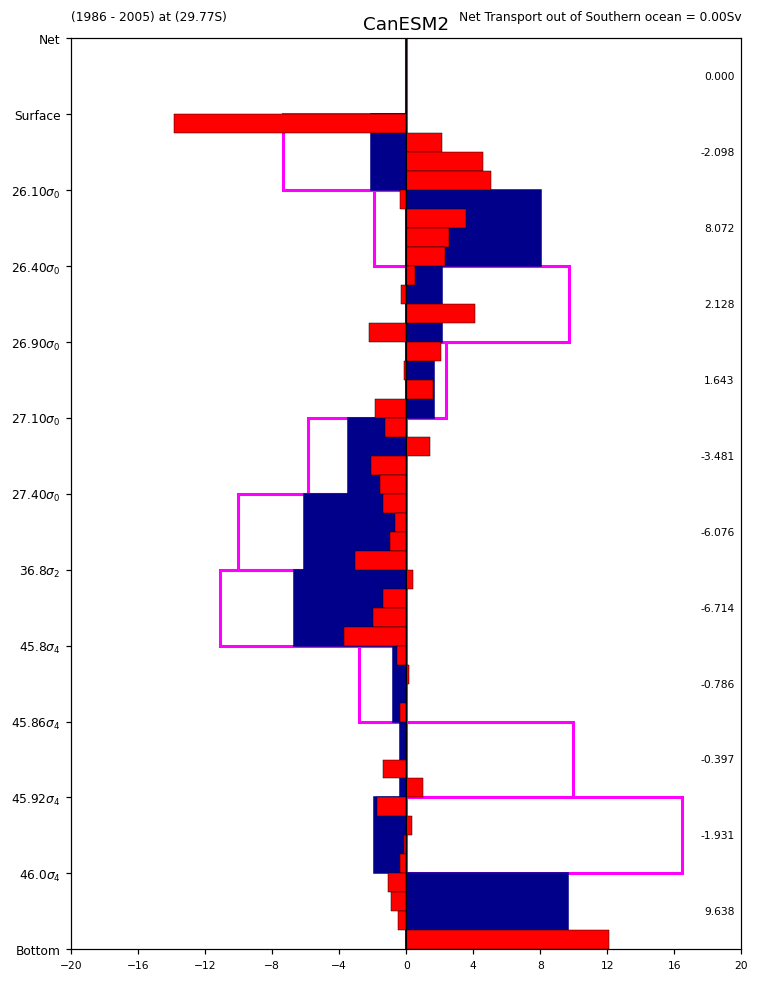

CanESM2: net = 0.000 Sv


2026-09-22 08:24:58,402 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
Process Dask Worker process (from Nanny):
Traceback (most recent call last):
Traceback (most recent call last):
2026-09-22 08:24:58,404 - distributed.nanny - ERROR - Worker process died unexpectedly
Process Dask Worker process (from Nanny):
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/asyncio/runners.py", line 118, in run
    return self._loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/asyncio/base_events.py", line 691, in run_until_complete
    return future.result()
           ^^^^^^^^^^^^^^^
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/distributed/nanny.py", line 985, in run
    await worker.finished()
  File "/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/

In [10]:
# Observed transports of Talley (2008), per density layer
talley = [0.0, -7.34, -1.9, 9.71, 2.37, -5.86, -10.02,
          -11.11, -2.84, 9.96, 16.49, 0.51]

for name in vo_cubes:
    section = prepare_section(thetao_cubes[name], so_cubes[name],
                              vo_cubes[name], volcello_cubes[name])

    # volume transport per cell, m3/s -> Sv
    transport = section["vo"] * section["area"] / 1.0e6

    main, sub = layer_sums(section["sigma"], transport)

    plot_layer_bars(main, sub, talley, name, "1986 - 2005",
                    section["exact_lat"], 20.0, 4.0, "Sv",
                    "Net Transport out of Southern ocean")
    plt.show()

    print(f"{name}: net = {main[0]:.3f} Sv")

**Figure 6a: Density-layer volume transport:** Volume transport (Sv) across 30S per density layer. Blue: layer totals,
red: subdivisions, magenta: observed values of Talley (2008).